# Copeland Method

In [18]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

sys.path.insert(0, '/home/jennifer/distortion')
from utils_3 import (
    copeland_from_population_utilities,
    borda_from_population_utilities,
    peeling_borda_from_population_utilities,
    argmax_lottery_from_population_utilities,
    nonzero_max_from_population_utilities,
    leaderboard_dist,
    _pairwise_win_probabilities_from_population_utilities,
    _normalize_distribution,
)

## Synthetic population

In [19]:
M = 10
N = 10
rng = np.random.default_rng(42)

utilities = rng.standard_normal((N, M))
voter_dist = np.ones(N, dtype=float) / N
cand_dist  = np.ones(M, dtype=float) / M

avg_utilities = voter_dist @ utilities
true_ranking  = np.argsort(-avg_utilities)

print("avg_utilities:", np.round(avg_utilities, 3))
print("true ranking:", true_ranking)

avg_utilities: [ 0.234 -0.24  -0.214  0.163 -0.368 -0.128 -0.106 -0.132  0.263  0.025]
true ranking: [8 0 3 9 6 5 7 2 1 4]


## Copeland ranking

Candidate $i$ receives the total opponent mass it beats minus the mass it loses to (ties contribute zero).
Implemented in `utils_3.copeland_from_population_utilities`.

In [20]:
scores, ranking = copeland_from_population_utilities(
    utilities, voter_dist=voter_dist, cand_dist=cand_dist, beta=1.0
)
print("Copeland scores:", np.round(scores, 4))
print("Copeland ranking:", ranking)
print("True ranking:    ", true_ranking)
print("Distortion:", round(leaderboard_dist(ranking, true_ranking, avg_utilities)[0], 4))

Copeland scores: [ 0.7 -0.7 -0.3  0.5 -0.9 -0.1  0.1 -0.5  0.9  0.3]
Copeland ranking: [8 0 3 9 6 5 2 7 1 4]
True ranking:     [8 0 3 9 6 5 7 2 1 4]
Distortion: 1.3448


## Copeland peeling

At each round:
1. Restrict pairwise win-rate matrix to the remaining candidates and re-weight `cand_dist`
2. Compute Copeland scores on the restricted set
3. Place the top scorer next in the ranking
4. Remove that candidate and repeat

In [21]:
def copeland_peeling_from_population_utilities(
    utilities,
    voter_dist=None,
    cand_dist=None,
    beta=1.0,
    tie_tol=1e-12,
):
    """
    Peeling ranking using Copeland scores.

    At each round, restrict to remaining candidates, re-normalise cand_dist,
    compute Copeland scores, place the winner, and repeat.

    Returns:
        round_scores: list of Copeland score arrays, one per round
        ranking:      array (C,) of candidate indices, best to worst
    """
    utilities  = np.asarray(utilities, dtype=float)
    V, C = utilities.shape
    voter_dist = _normalize_distribution(voter_dist, V, "voter_dist")
    cand_dist  = _normalize_distribution(cand_dist,  C, "cand_dist")

    remaining   = list(range(C))
    ranking     = []
    round_scores = []

    while remaining:
        rem = np.array(remaining)
        rem_utils     = utilities[:, rem]
        rem_cand_dist = cand_dist[rem] / cand_dist[rem].sum()

        P = _pairwise_win_probabilities_from_population_utilities(
            rem_utils, voter_dist=voter_dist, beta=beta,
        )
        margins = P - P.T
        wins   = margins >  tie_tol
        losses = margins < -tie_tol
        np.fill_diagonal(wins,   False)
        np.fill_diagonal(losses, False)

        scores = wins.astype(float) @ rem_cand_dist - losses.astype(float) @ rem_cand_dist
        round_scores.append(scores.copy())

        winner_local  = int(np.argmax(scores))
        winner_global = remaining[winner_local]
        ranking.append(winner_global)
        remaining.pop(winner_local)

    return round_scores, np.array(ranking, dtype=int)

In [22]:
_, ranking_peeling = copeland_peeling_from_population_utilities(
    utilities, voter_dist=voter_dist, cand_dist=cand_dist, beta=1.0
)
print("Copeland peeling ranking:", ranking_peeling)
print("Copeland flat ranking:   ", ranking)
print("True ranking:            ", true_ranking)
print("Copeland peeling distortion:", round(leaderboard_dist(ranking_peeling, true_ranking, avg_utilities)[0], 4))
print("Copeland flat distortion:   ", round(leaderboard_dist(ranking, true_ranking, avg_utilities)[0], 4))

Copeland peeling ranking: [8 0 3 9 6 5 2 7 1 4]
Copeland flat ranking:    [8 0 3 9 6 5 2 7 1 4]
True ranking:             [8 0 3 9 6 5 7 2 1 4]
Copeland peeling distortion: 1.3448
Copeland flat distortion:    1.3448


## Distortion vs β — single population and averaged over 200 populations

In [23]:
betas = np.asarray([0.01, 0.1, 0.5, 1.0, 2.0, 3, 5.0, 10.0, 15.0, 20, 25, 30.0, 35, 40.0, 45, 50, 60, 70, 80, 90, 100, 200])

methods = ['borda', 'borda_peeling', 'copeland', 'copeland_peeling']

style = {
    'borda':             dict(marker='o', linestyle='-',  color='C0', label='Borda'),
    'borda_peeling':     dict(marker='s', linestyle='--', color='C1', label='Borda (peeling)'),
    'copeland':          dict(marker='^', linestyle='-',  color='C2', label='Copeland'),
    'copeland_peeling':  dict(marker='D', linestyle='--', color='C3', label='Copeland (peeling)'),
}


def compute_distortions(utilities, voter_dist, avg_utils, betas, cand_dist=None):
    C = utilities.shape[1]
    true_rank = np.argsort(-avg_utils)
    if cand_dist is None:
        cand_dist = np.ones(C, dtype=float) / C
    out = {m: [] for m in methods}
    for b in betas:
        _, r = borda_from_population_utilities(utilities, voter_dist=voter_dist, cand_dist=cand_dist, beta=b)
        out['borda'].append(leaderboard_dist(r, true_rank, avg_utils)[0])

        s, r = copeland_from_population_utilities(utilities, voter_dist=voter_dist, cand_dist=cand_dist, beta=b)
        out['copeland'].append(leaderboard_dist(r, true_rank, avg_utils)[0])

        # peeling variants — reuse borda peeling from utils_3
        from utils_3 import peeling_borda_from_population_utilities
        _, r = peeling_borda_from_population_utilities(utilities, voter_dist=voter_dist, cand_dist=cand_dist, beta=b)
        out['borda_peeling'].append(leaderboard_dist(r, true_rank, avg_utils)[0])

        _, r = copeland_peeling_from_population_utilities(utilities, voter_dist=voter_dist, cand_dist=cand_dist, beta=b)
        out['copeland_peeling'].append(leaderboard_dist(r, true_rank, avg_utils)[0])

    return out


# single population (seed 42)
d42 = compute_distortions(utilities, voter_dist, avg_utilities, betas, cand_dist)
for m in methods:
    print(m, np.round(d42[m], 4))

borda [1.     1.     1.     1.     1.     1.     1.     1.     1.     1.3448
 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448
 1.3448 1.3448]
borda_peeling [1.     1.     1.     1.3347 1.3347 1.3347 1.3347 1.5134 1.5134 1.5134
 1.5134 1.5134 1.5134 1.5134 1.5134 1.5134 1.5134 1.5134 1.5134 1.5134
 1.5134 1.5134]
copeland [1.     1.     1.     1.3448 1.     1.1242 1.1242 1.1242 1.1242 1.1242
 1.1242 1.1242 1.1242 1.1242 1.1242 1.1242 1.1242 1.1242 1.1242 1.1242
 1.1242 1.1242]
copeland_peeling [1.     1.     1.     1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448
 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448 1.3448
 1.3448 1.3448]


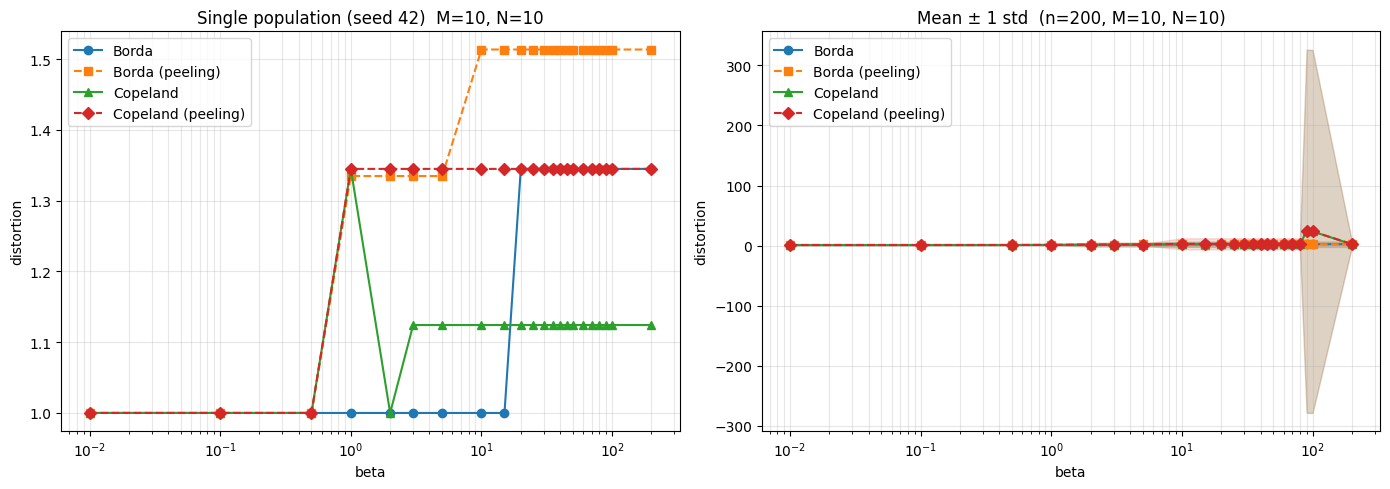

In [24]:
n_populations = 200
M_bulk, N_bulk = 10, 10
rng_bulk = np.random.default_rng(0)
cand_dist_bulk = np.ones(M_bulk, dtype=float) / M_bulk

all_distortions = {m: [] for m in methods}

for _ in range(n_populations):
    utils = rng_bulk.standard_normal((N_bulk, M_bulk))
    vdist = np.ones(N_bulk, dtype=float) / N_bulk
    avg   = vdist @ utils
    d = compute_distortions(utils, vdist, avg, betas, cand_dist=cand_dist_bulk)
    for m in methods:
        all_distortions[m].append(d[m])

mean_dist = {m: np.nanmean(all_distortions[m], axis=0) for m in methods}
std_dist  = {m: np.nanstd(all_distortions[m],  axis=0) for m in methods}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.set_title(f'Single population (seed 42)  M={M}, N={N}')
for m, kw in style.items():
    ax.plot(betas, d42[m], **kw)
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

ax = axes[1]
ax.set_title(f'Mean ± 1 std  (n={n_populations}, M={M_bulk}, N={N_bulk})')
for m, kw in style.items():
    c = kw['color']
    ax.plot(betas, mean_dist[m], **kw)
    ax.fill_between(betas, mean_dist[m] - std_dist[m], mean_dist[m] + std_dist[m],
                    alpha=0.15, color=c)
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.legend()
ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

## Using the real dataset

In [25]:
from utils_3 import PairwiseData, Population

import os
for k in ["HF_HOME", "HF_HUB_CACHE", "HF_DATASETS_CACHE", "XDG_CACHE_HOME"]:
    print(k, os.environ.get(k))

from datasets import load_dataset

ds = load_dataset(
    "lmarena-ai/arena-human-preference-140k") 
ds = dict(ds)

pw = PairwiseData(ds, M=30, N=30)
population = Population(pw)

HF_HOME /home/jennifer/scratch/hf
HF_HUB_CACHE None
HF_DATASETS_CACHE /home/jennifer/scratch/hf/datasets
XDG_CACHE_HOME None


100%|██████████| 30/30 [00:01<00:00, 29.66it/s]


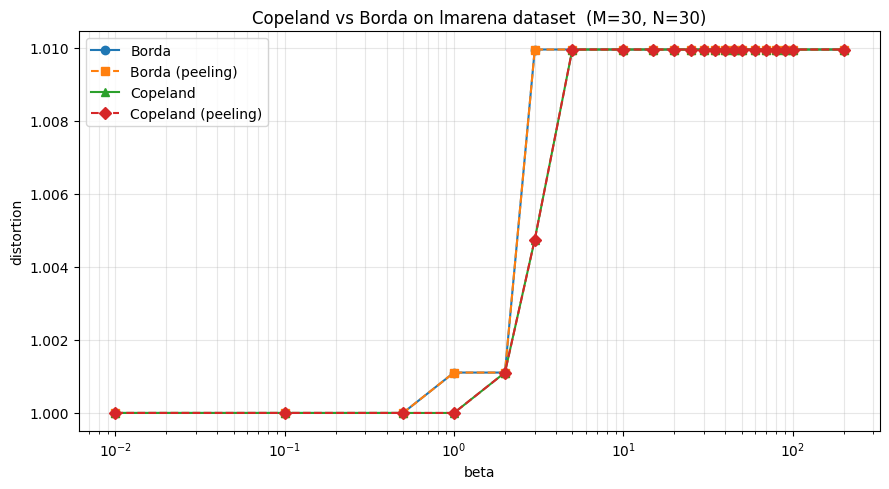

borda                 [1.     1.     1.     1.0011 1.0011 1.01   1.01   1.01   1.01   1.01
 1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01
 1.01   1.01  ]
borda_peeling         [1.     1.     1.     1.0011 1.0011 1.01   1.01   1.01   1.01   1.01
 1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01
 1.01   1.01  ]
copeland              [1.     1.     1.     1.     1.0011 1.0047 1.01   1.01   1.01   1.01
 1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01
 1.01   1.01  ]
copeland_peeling      [1.     1.     1.     1.     1.0011 1.0047 1.01   1.01   1.01   1.01
 1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01
 1.01   1.01  ]


In [26]:
real_avg_utils = population.avg_utilities
real_true_rank = np.argsort(-real_avg_utils)
candidate_labels = [pw.idx_to_candidates[i] for i in range(pw.M)]

d_real = compute_distortions(
    population.population_utilities,
    population.voter_distr,
    real_avg_utils,
    betas,
    cand_dist=pw.candidate_distr,
)

fig, ax = plt.subplots(figsize=(9, 5))
for m, kw in style.items():
    ax.plot(betas, d_real[m], **kw)
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion')
ax.set_title(f'Copeland vs Borda on lmarena dataset  (M={pw.M}, N={pw.N})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

for m in methods:
    print(f"{m:20s}  {np.round(d_real[m], 4)}")

In [27]:
# Rankings at beta=1.0
beta_show = 1.0

_, r_borda    = borda_from_population_utilities(
    population.population_utilities, voter_dist=population.voter_distr,
    cand_dist=pw.candidate_distr, beta=beta_show)
_, r_copeland = copeland_from_population_utilities(
    population.population_utilities, voter_dist=population.voter_distr,
    cand_dist=pw.candidate_distr, beta=beta_show)
_, r_borda_p  = peeling_borda_from_population_utilities(
    population.population_utilities, voter_dist=population.voter_distr,
    cand_dist=pw.candidate_distr, beta=beta_show)
_, r_cop_p    = copeland_peeling_from_population_utilities(
    population.population_utilities, voter_dist=population.voter_distr,
    cand_dist=pw.candidate_distr, beta=beta_show)

print(f"Rankings at beta={beta_show}  (rank 1 = best)")
print(f"{'Rank':>4}  {'True':^28}  {'Borda':^28}  {'Borda peel':^28}  {'Copeland':^28}  {'Copeland peel':^28}")
print("-" * 148)
for rank in range(pw.M):
    print(
        f"{rank+1:>4}  "
        f"{candidate_labels[real_true_rank[rank]]:^28}  "
        f"{candidate_labels[r_borda[rank]]:^28}  "
        f"{candidate_labels[r_borda_p[rank]]:^28}  "
        f"{candidate_labels[r_copeland[rank]]:^28}  "
        f"{candidate_labels[r_cop_p[rank]]:^28}"
    )

Rankings at beta=1.0  (rank 1 = best)
Rank              True                         Borda                       Borda peel                     Copeland                   Copeland peel        
----------------------------------------------------------------------------------------------------------------------------------------------------
   1         gemini-2.5-pro                gemini-2.5-pro                gemini-2.5-pro                gemini-2.5-pro                gemini-2.5-pro       
   2         o3-2025-04-16                 o3-2025-04-16                 o3-2025-04-16                 o3-2025-04-16                 o3-2025-04-16        
   3   chatgpt-4o-latest-20250326    chatgpt-4o-latest-20250326    chatgpt-4o-latest-20250326    chatgpt-4o-latest-20250326    chatgpt-4o-latest-20250326 
   4      grok-3-preview-02-24          grok-3-preview-02-24          grok-3-preview-02-24          grok-3-preview-02-24          grok-3-preview-02-24    
   5        deepseek-r1-0528          

## Fixed weight set distortion on the real dataset

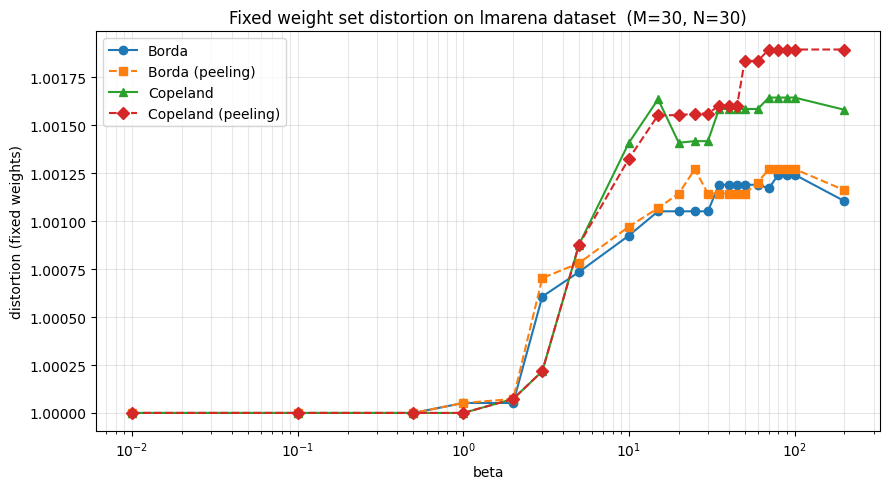

borda                 [1.     1.     1.     1.0001 1.0001 1.0006 1.0007 1.0009 1.0011 1.0011
 1.0011 1.0011 1.0012 1.0012 1.0012 1.0012 1.0012 1.0012 1.0012 1.0012
 1.0012 1.0011]
borda_peeling         [1.     1.     1.     1.0001 1.0001 1.0007 1.0008 1.001  1.0011 1.0011
 1.0013 1.0011 1.0011 1.0011 1.0011 1.0011 1.0012 1.0013 1.0013 1.0013
 1.0013 1.0012]
copeland              [1.     1.     1.     1.     1.0001 1.0002 1.0009 1.0014 1.0016 1.0014
 1.0014 1.0014 1.0016 1.0016 1.0016 1.0016 1.0016 1.0016 1.0016 1.0016
 1.0016 1.0016]
copeland_peeling      [1.     1.     1.     1.     1.0001 1.0002 1.0009 1.0013 1.0016 1.0016
 1.0016 1.0016 1.0016 1.0016 1.0016 1.0018 1.0018 1.0019 1.0019 1.0019
 1.0019 1.0019]


In [28]:
def leaderboard_dist_w(ranking, true_ranking, avg_utils, w):
    avg_utils = avg_utils - avg_utils.min()  # shift to non-negative
    ranking_utils      = avg_utils[np.asarray(ranking)]
    true_ranking_utils = avg_utils[np.asarray(true_ranking)]
    return (true_ranking_utils * w).sum() / (ranking_utils * w).sum(), None


def compute_distortions_w(utilities, voter_dist, avg_utils, betas, w, cand_dist=None):
    C = utilities.shape[1]
    true_rank = np.argsort(-avg_utils)
    if cand_dist is None:
        cand_dist = np.ones(C, dtype=float) / C
    out = {m: [] for m in methods}
    for b in betas:
        _, r = borda_from_population_utilities(
            utilities, voter_dist=voter_dist, cand_dist=cand_dist, beta=b)
        out['borda'].append(leaderboard_dist_w(r, true_rank, avg_utils, w)[0])

        _, r = copeland_from_population_utilities(
            utilities, voter_dist=voter_dist, cand_dist=cand_dist, beta=b)
        out['copeland'].append(leaderboard_dist_w(r, true_rank, avg_utils, w)[0])

        _, r = peeling_borda_from_population_utilities(
            utilities, voter_dist=voter_dist, cand_dist=cand_dist, beta=b)
        out['borda_peeling'].append(leaderboard_dist_w(r, true_rank, avg_utils, w)[0])

        _, r = copeland_peeling_from_population_utilities(
            utilities, voter_dist=voter_dist, cand_dist=cand_dist, beta=b)
        out['copeland_peeling'].append(leaderboard_dist_w(r, true_rank, avg_utils, w)[0])

    return out


w = 1 / (1.1 ** np.arange(pw.M))

d_real_w = compute_distortions_w(
    population.population_utilities,
    population.voter_distr,
    real_avg_utils,
    betas,
    w,
    cand_dist=pw.candidate_distr,
)

fig, ax = plt.subplots(figsize=(9, 5))
for m, kw in style.items():
    ax.plot(betas, d_real_w[m], **kw)
ax.set_xscale('log')
ax.set_xlabel('beta')
ax.set_ylabel('distortion (fixed weights)')
ax.set_title(f'Fixed weight set distortion on lmarena dataset  (M={pw.M}, N={pw.N})')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

for m in methods:
    print(f"{m:20s}  {np.round(d_real_w[m], 4)}")

## Dependent candidate distribution: xy_conditioned_on_x

In [29]:
# Joint distribution over ordered pairs (symmetric: both (w,l) and (l,w) counted)
mu = np.zeros((pw.M, pw.M))
for wi, li in zip(pw.winners, pw.losers):
    mu[wi, li] += 1.0
    mu[li, wi] += 1.0
mu /= len(pw.winners)

# Marginal appearance probability of each candidate
empirical_distr = mu.sum(axis=1)  # row sums of symmetric mu = marginal

# Conditional: row i is P(opponent = j | candidate i appears)
xy_conditioned_on_x = np.zeros_like(mu)
for i in range(pw.M):
    if empirical_distr[i] > 0:
        xy_conditioned_on_x[i] = mu[i] / empirical_distr[i]

print("row sums (should all be ~1):", np.round(xy_conditioned_on_x.sum(axis=1), 4))


def borda_rank_2d(utilities, voter_dist, cand_dist_2d, beta):
    """Borda scores with per-candidate opponent distribution."""
    P = _pairwise_win_probabilities_from_population_utilities(
        utilities, voter_dist=voter_dist, beta=beta)
    return np.argsort(-(P * cand_dist_2d).sum(axis=1))


def borda_peeling_rank_2d(utilities, voter_dist, cand_dist_2d, beta):
    C = utilities.shape[1]
    remaining = list(range(C))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        P = _pairwise_win_probabilities_from_population_utilities(
            utilities[:, rem], voter_dist=voter_dist, beta=beta)
        sub = cand_dist_2d[np.ix_(rem, rem)]
        row_sums = sub.sum(axis=1, keepdims=True)
        sub = sub / np.where(row_sums == 0, 1.0, row_sums)
        winner_local = int(np.argmax((P * sub).sum(axis=1)))
        ranking.append(remaining[winner_local])
        remaining.pop(winner_local)
    return np.array(ranking, dtype=int)


def copeland_rank_2d(utilities, voter_dist, cand_dist_2d, beta, tie_tol=1e-12):
    """Copeland scores with per-candidate opponent distribution."""
    P = _pairwise_win_probabilities_from_population_utilities(
        utilities, voter_dist=voter_dist, beta=beta)
    margins = P - P.T
    wins   = (margins >  tie_tol).astype(float)
    losses = (margins < -tie_tol).astype(float)
    np.fill_diagonal(wins, 0); np.fill_diagonal(losses, 0)
    return np.argsort(-((wins - losses) * cand_dist_2d).sum(axis=1))


def copeland_peeling_rank_2d(utilities, voter_dist, cand_dist_2d, beta, tie_tol=1e-12):
    C = utilities.shape[1]
    remaining = list(range(C))
    ranking = []
    while remaining:
        rem = np.array(remaining)
        P = _pairwise_win_probabilities_from_population_utilities(
            utilities[:, rem], voter_dist=voter_dist, beta=beta)
        sub = cand_dist_2d[np.ix_(rem, rem)]
        row_sums = sub.sum(axis=1, keepdims=True)
        sub = sub / np.where(row_sums == 0, 1.0, row_sums)
        margins = P - P.T
        wins   = (margins >  tie_tol).astype(float)
        losses = (margins < -tie_tol).astype(float)
        np.fill_diagonal(wins, 0); np.fill_diagonal(losses, 0)
        winner_local = int(np.argmax(((wins - losses) * sub).sum(axis=1)))
        ranking.append(remaining[winner_local])
        remaining.pop(winner_local)
    return np.array(ranking, dtype=int)

row sums (should all be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


In [30]:
rank_fns_2d = {
    'borda':            borda_rank_2d,
    'borda_peeling':    borda_peeling_rank_2d,
    'copeland':         copeland_rank_2d,
    'copeland_peeling': copeland_peeling_rank_2d,
}

# supremum distortion with dependent distribution
d_dep = {m: [] for m in methods}
# fixed-weight distortion with dependent distribution
d_dep_w = {m: [] for m in methods}

for b in betas:
    for m, fn in rank_fns_2d.items():
        r = fn(population.population_utilities, population.voter_distr,
               xy_conditioned_on_x, b)
        d_dep[m].append(leaderboard_dist(r, real_true_rank, real_avg_utils)[0])
        d_dep_w[m].append(leaderboard_dist_w(r, real_true_rank, real_avg_utils, w)[0])

In [31]:
# ML methods have no cand_dist, so no independent/dependent distinction
ml_methods = ['ml_argmax', 'ml_nonzero']
ml_style = {
    'ml_argmax':  dict(marker='h', linestyle='-', color='C4', label='ML argmax peeling'),
    'ml_nonzero': dict(marker='p', linestyle='-', color='C5', label='ML nonzero peeling'),
}

d_ml   = {m: [] for m in ml_methods}
d_ml_w = {m: [] for m in ml_methods}

for b in betas:
    for key, fn in [('ml_argmax', argmax_lottery_from_population_utilities),
                    ('ml_nonzero', nonzero_max_from_population_utilities)]:
        try:
            _, r = fn(population.population_utilities,
                      voter_dist=population.voter_distr, beta=b)
            d_ml[key].append(leaderboard_dist(r, real_true_rank, real_avg_utils)[0])
            d_ml_w[key].append(leaderboard_dist_w(r, real_true_rank, real_avg_utils, w)[0])
        except RuntimeError:
            d_ml[key].append(float('nan'))
            d_ml_w[key].append(float('nan'))

for m in ml_methods:
    print(f"{m}  supremum: {np.round(d_ml[m], 4)}")
    print(f"{m}  fixed-w:  {np.round(d_ml_w[m], 4)}")

ml_argmax  supremum: [1.     1.     1.     1.     1.0011 1.0047 1.01   1.01   1.01   1.01
 1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01
 1.01   1.01  ]
ml_argmax  fixed-w:  [1.     1.     1.     1.     1.0001 1.0002 1.0009 1.0013 1.0016 1.0016
 1.0016 1.0016 1.0016 1.0016 1.0016 1.0017 1.0018 1.0019 1.0019 1.0019
 1.0019 1.0017]
ml_nonzero  supremum: [1.     1.     1.     1.     1.0011 1.0047 1.01   1.01   1.01   1.01
 1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01   1.01
 1.01   1.01  ]
ml_nonzero  fixed-w:  [1.     1.     1.     1.     1.0001 1.0002 1.0009 1.0014 1.0016 1.0015
 1.0015 1.0015 1.0015 1.0017 1.0017 1.0018 1.0018 1.0019 1.0019 1.0019
 1.0019 1.0011]


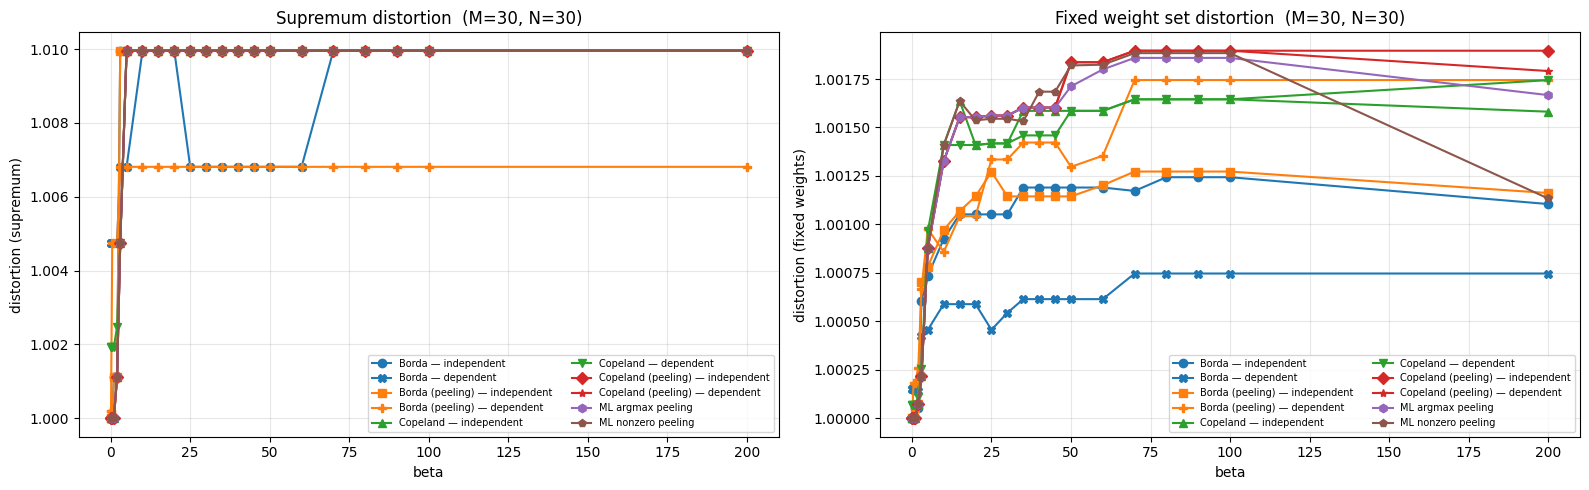

In [32]:
markers_indep = {'borda': 'o', 'borda_peeling': 's', 'copeland': '^', 'copeland_peeling': 'D'}
markers_dep   = {'borda': 'X', 'borda_peeling': 'P', 'copeland': 'v', 'copeland_peeling': '*'}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (d_indep, d_dep_cur, d_ml_cur), ylabel, title in zip(
    axes,
    [(d_real, d_dep, d_ml), (d_real_w, d_dep_w, d_ml_w)],
    ['distortion (supremum)', 'distortion (fixed weights)'],
    ['Supremum distortion', 'Fixed weight set distortion'],
):
    for m, kw in style.items():
        c = kw['color']
        ax.plot(betas, d_indep[m], color=c, linestyle='-',
                marker=markers_indep[m], label=f"{kw['label']} — independent")
        ax.plot(betas, d_dep_cur[m], color=c, linestyle='-',
                marker=markers_dep[m],   label=f"{kw['label']} — dependent")

    for m, kw in ml_style.items():
        ax.plot(betas, d_ml_cur[m], color=kw['color'], linestyle='-',
                marker=kw['marker'], label=kw['label'])

    # ax.set_xscale('log')
    ax.set_xlabel('beta')
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title}  (M={pw.M}, N={pw.N})')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

Copeland shouldn't depend on independent versus dependent?